In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path1 = "C:/Users/ayana/Downloads/gender_submission.csv"
file_path2 = "C:/Users/ayana/Downloads/test.csv"
file_path3 = "C:/Users/ayana/Downloads/train.csv"

In [5]:
df1 = pd.read_csv("C:/Users/ayana/Downloads/gender_submission.csv")
df2 = pd.read_csv("C:/Users/ayana/Downloads/test.csv")
df3 = pd.read_csv("C:/Users/ayana/Downloads/train.csv")


In [6]:
print(df1.head())
print(df2.head())
print(df3.head())

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  
   PassengerId  Survived  P

Check for missing values

In [9]:
# Check for missing values in each dataset
missing_values_df1 = df1.isnull().sum()
missing_values_df2 = df2.isnull().sum()
missing_values_df3 = df3.isnull().sum()

In [11]:
# Display the missing values for each dataframe
print("Missing values in df1:", missing_values_df1)
print("Missing values in df2:", missing_values_df2)
print("Missing values in df3:", missing_values_df3)

Missing values in df1: PassengerId    0
Survived       0
dtype: int64
Missing values in df2: PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
Missing values in df3: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Handle Missing values

In [13]:
# Fill missing 'Age' values with the median of the 'Age' column
df3['Age'].fillna(df3['Age'].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [14]:
# Check if missing values are handled in 'Age'
print(df3.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [15]:
# Drop the 'Cabin' column
df3.drop(columns=['Cabin'], inplace=True)

In [16]:
# Verify if the column is dropped
print(df3.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [18]:
# Fill missing 'Embarked' values with the mode (most frequent value)
df3['Embarked'].fillna(df3['Embarked'].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [19]:
# Verify the change
print(df3.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Check data types and info

In [20]:
df1.info()
df2.info()
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory 

Summary Statistics

In [21]:
df1.describe()
df2.describe()
df3.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Visualizing the data

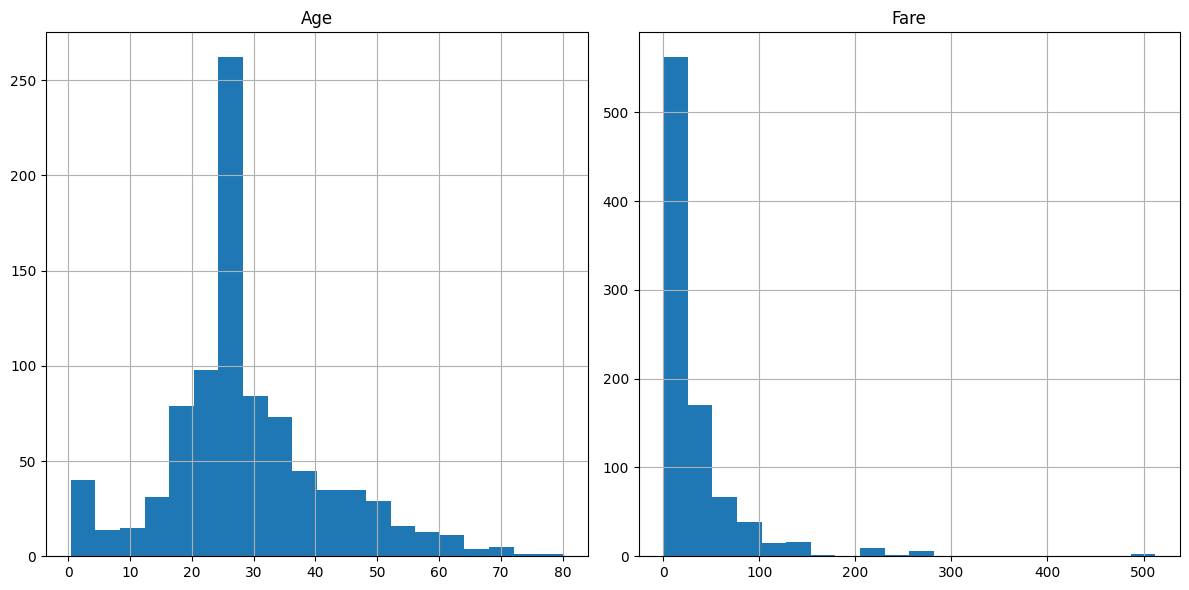

In [22]:
# Plot histograms for numerical features
df3[['Age', 'Fare']].hist(bins=20, figsize=(12, 6))
plt.tight_layout()
plt.show()

Bar Plots for Categorical Features

In [23]:
import seaborn as sns

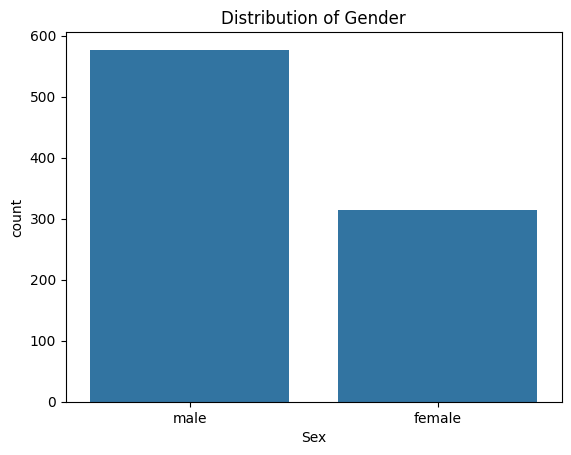

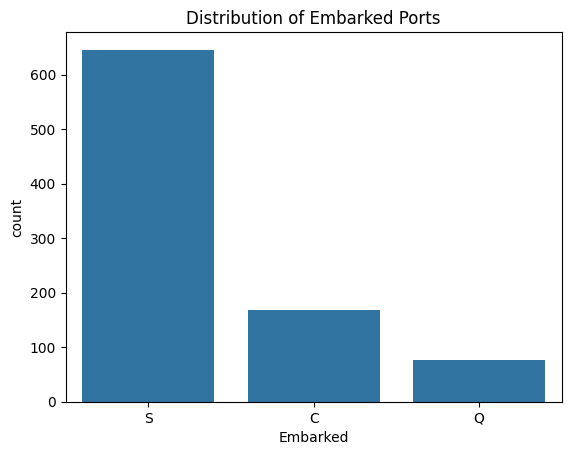

In [24]:
# Plot bar charts for categorical features
sns.countplot(x='Sex', data=df3)
plt.title('Distribution of Gender')
plt.show()

sns.countplot(x='Embarked', data=df3)
plt.title('Distribution of Embarked Ports')
plt.show()

In [26]:
# Select only numerical columns for correlation
numerical_columns = df3.select_dtypes(include=['float64', 'int64'])

In [27]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = numerical_columns.corr()


In [28]:
# Plot the correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt


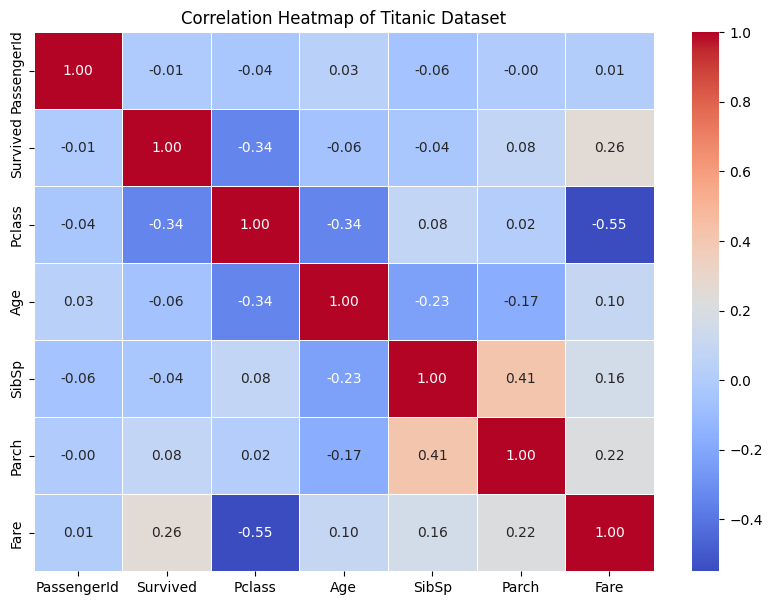

In [29]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Dataset')
plt.show()

Survival Rate by Gender

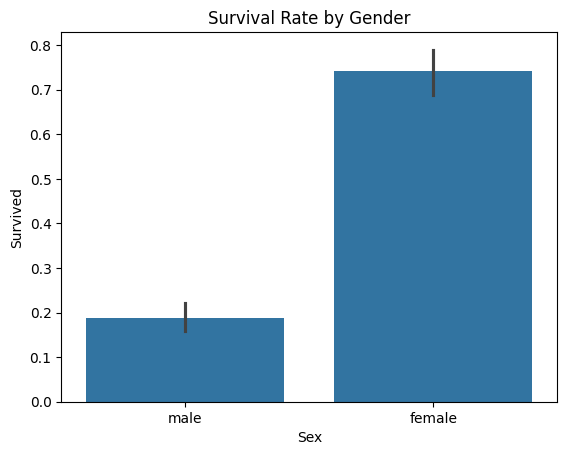

In [31]:
# Plot survival rate by gender
sns.barplot(x='Sex', y='Survived', data=df3)
plt.title('Survival Rate by Gender')
plt.show()

Survival Rate by Passenger Class (Pclass)

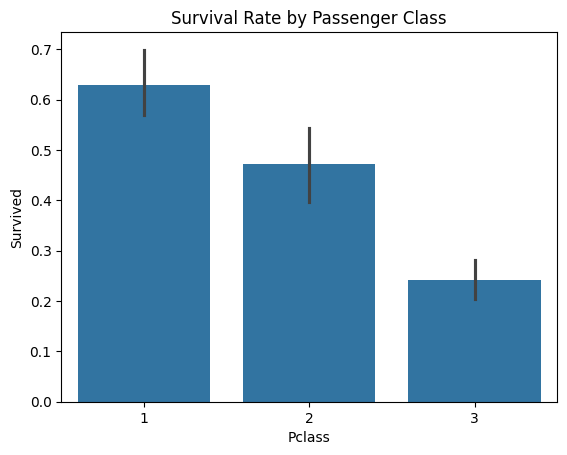

In [32]:
# Plot survival rate by passenger class
sns.barplot(x='Pclass', y='Survived', data=df3)
plt.title('Survival Rate by Passenger Class')
plt.show()

Survival Rate by Embarked Port

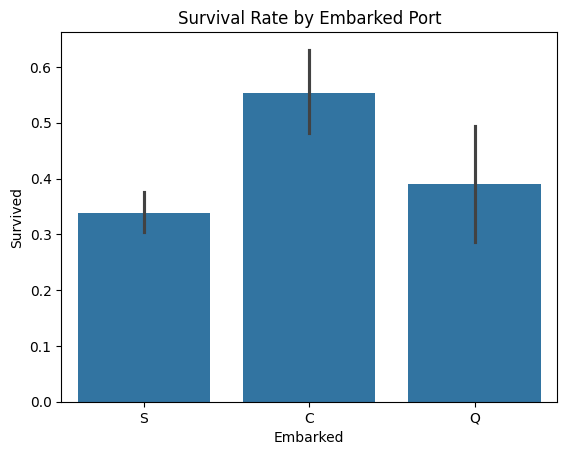

In [33]:
# Plot survival rate by Embarked (Port of Embarkation)
sns.barplot(x='Embarked', y='Survived', data=df3)
plt.title('Survival Rate by Embarked Port')
plt.show()

Age VS Survival

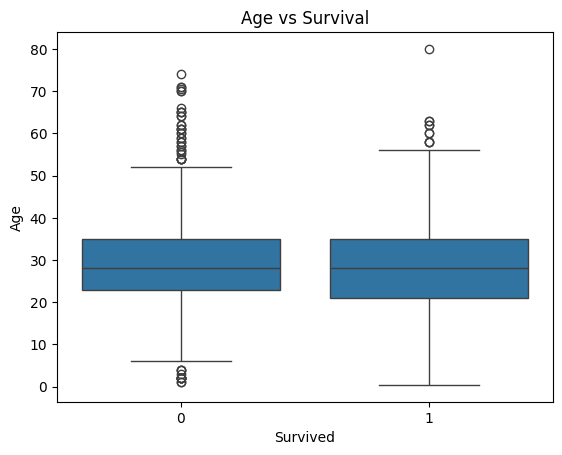

In [34]:
# Plot Age vs Survival
sns.boxplot(x='Survived', y='Age', data=df3)
plt.title('Age vs Survival')
plt.show()

Fare VS Survival

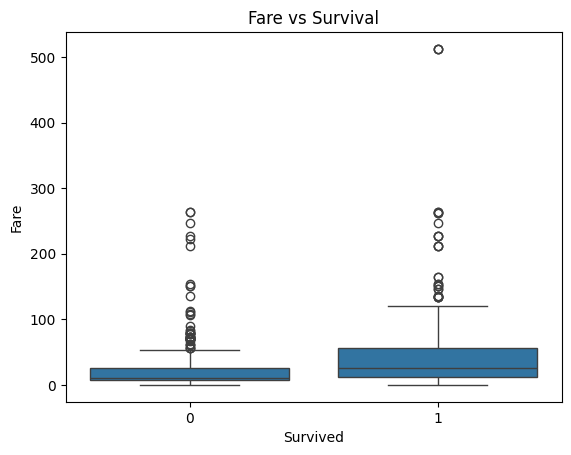

In [35]:
# Plot Fare vs Survival
sns.boxplot(x='Survived', y='Fare', data=df3)
plt.title('Fare vs Survival')
plt.show()

Visualize Relationships Between Features

In [36]:
# Create a new feature 'FamilySize' by combining 'SibSp' and 'Parch'
df3['FamilySize'] = df3['SibSp'] + df3['Parch']


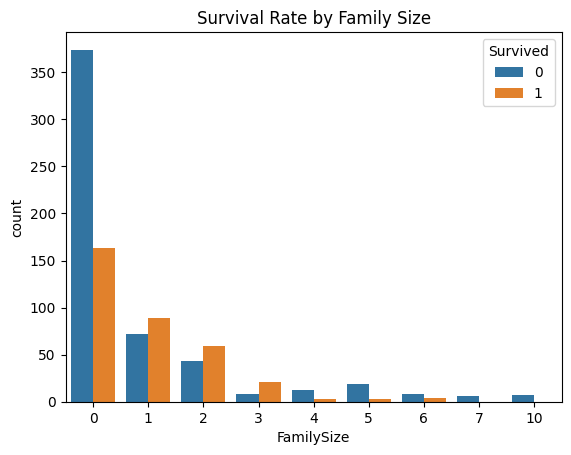

In [37]:
# Plot survival rate by family size
sns.countplot(x='FamilySize', hue='Survived', data=df3)
plt.title('Survival Rate by Family Size')
plt.show()

Age and Survival (with Categories)

In [38]:
# Create age bins (groups)
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['0-12', '13-18', '19-35', '36-60', '60+']
df3['AgeGroup'] = pd.cut(df3['Age'], bins=age_bins, labels=age_labels)

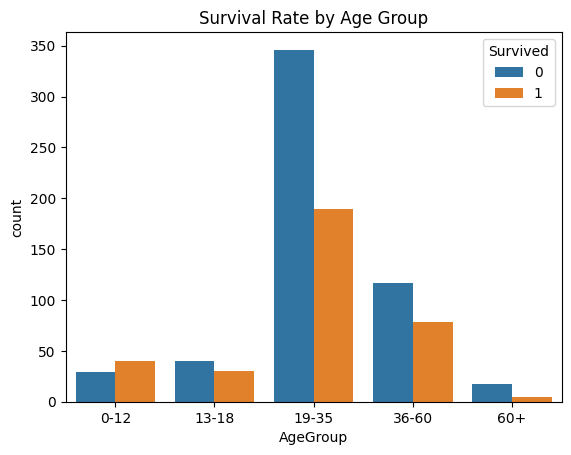

In [39]:
# Plot survival rate by Age Group
sns.countplot(x='AgeGroup', hue='Survived', data=df3)
plt.title('Survival Rate by Age Group')
plt.show()

Fare and Survival

In [40]:
# Create fare bins (ranges)
fare_bins = [0, 50, 100, 200, 300, 1000]
fare_labels = ['0-50', '51-100', '101-200', '201-300', '301+']
df3['FareGroup'] = pd.cut(df3['Fare'], bins=fare_bins, labels=fare_labels)

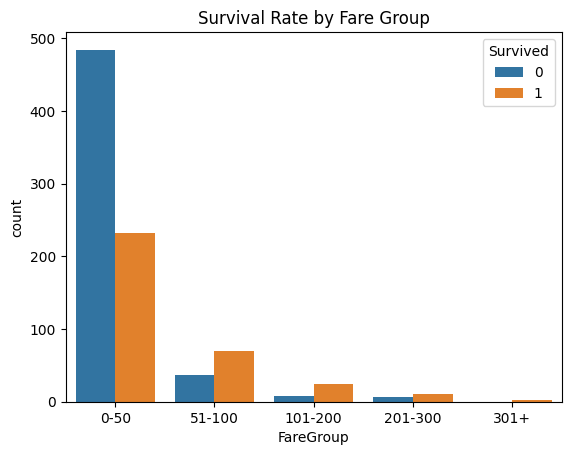

In [41]:
# Plot survival rate by Fare Group
sns.countplot(x='FareGroup', hue='Survived', data=df3)
plt.title('Survival Rate by Fare Group')
plt.show()

Creating a New Feature: Family Size

In [42]:
# Create a new feature 'FamilySize' by combining 'SibSp' and 'Parch'
df3['FamilySize'] = df3['SibSp'] + df3['Parch']

In [43]:
# Display the first few rows of the dataset to check the new feature
print(df3[['SibSp', 'Parch', 'FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           1
1      1      0           1
2      0      0           0
3      1      0           1
4      0      0           0


Extract Title from Name

In [44]:
# Extract title from Name (e.g., Mr, Mrs, Miss, etc.)
df3['Title'] = df3['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

In [45]:
# Display the unique titles
print(df3['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']


Create a Binary Feature: Is Alone

In [46]:
# Create a binary feature 'IsAlone'
df3['IsAlone'] = df3['FamilySize'].apply(lambda x: 1 if x == 0 else 0)


In [47]:
# Display the first few rows of the new feature
print(df3[['FamilySize', 'IsAlone']].head())

   FamilySize  IsAlone
0           1        0
1           1        0
2           0        1
3           1        0
4           0        1


Simplifying the Age Feature

In [48]:
# Create age bins (groups)
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior']
df3['AgeGroup'] = pd.cut(df3['Age'], bins=age_bins, labels=age_labels)

In [49]:
# Display the first few rows with the new 'AgeGroup' feature
print(df3[['Age', 'AgeGroup']].head())

    Age     AgeGroup
0  22.0        Adult
1  38.0  Middle-aged
2  26.0        Adult
3  35.0        Adult
4  35.0        Adult


Convert Categorical Features to Numeric (for modeling)

In [50]:
# Convert 'Sex' to binary numeric feature (0 for male, 1 for female)
df3['Sex'] = df3['Sex'].map({'male': 0, 'female': 1})

In [51]:
# Display the first few rows to verify
print(df3[['Sex']].head())

   Sex
0    0
1    1
2    1
3    1
4    0


One-Hot Encoding for Embarked (Since it has more than two categories)

In [52]:
# One-hot encode the 'Embarked' feature
df3 = pd.get_dummies(df3, columns=['Embarked'], drop_first=True)

In [54]:
print(df3.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'FamilySize', 'AgeGroup', 'FareGroup',
       'Title', 'IsAlone', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


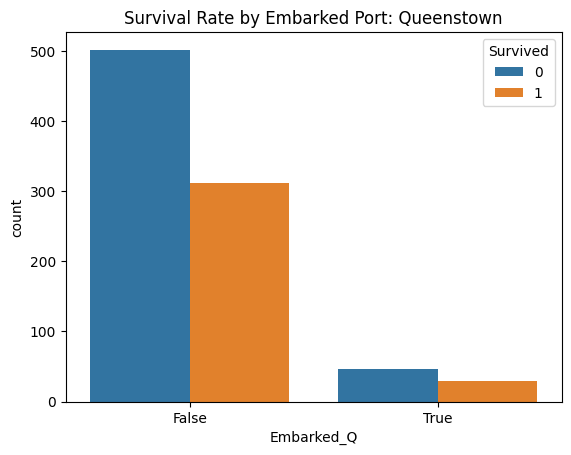

In [55]:
# Plot survival rate by Embarked port
sns.countplot(x='Embarked_Q', hue='Survived', data=df3)
plt.title('Survival Rate by Embarked Port: Queenstown')
plt.show()

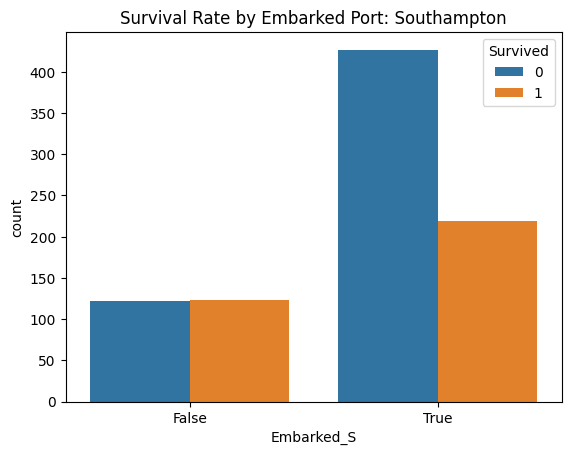

In [56]:
sns.countplot(x='Embarked_S', hue='Survived', data=df3)
plt.title('Survival Rate by Embarked Port: Southampton')
plt.show()

CONCLUSIONS

1. Impact of Gender on Survival:
Females had a significantly higher survival rate compared to males. This is consistent with historical accounts of the Titanic disaster, where women and children were prioritized during the evacuation process.
2. Passenger Class and Survival:
Passengers in First Class (Pclass = 1) had a higher survival rate compared to those in Second and Third Classes. This suggests that wealthier passengers had better access to lifeboats or were rescued first.
3. Embarked Port and Survival:
Passengers who embarked from Cherbourg (Embarked_C) had a higher survival rate than those from Queenstown (Embarked_Q) or Southampton (Embarked_S). This indicates that passengers boarding at Cherbourg may have been in a more favorable position when it came to evacuation.
4. Family Size and Survival:
Passengers traveling alone (with FamilySize = 0) had lower survival rates compared to those traveling with family members. Larger family groups were likely to have a better chance of survival, potentially due to their cooperation and the collective help of family members during evacuation.
5. Age and Survival:
Younger passengers (children) and older passengers had higher survival rates. This aligns with the well-documented fact that children and women were prioritized during the evacuation.
6. Fare and Survival:
Passengers who paid higher fare prices (likely in First Class) had a higher survival rate. This indicates that wealthier passengers had better access to resources, such as lifeboats, which increased their chances of survival.
7. Missing Data:
Age, Fare, and Embarked had missing values, but these were handled effectively:
Age was filled with the median value.
Fare was filled with the median value.
Embarked was filled with the mode value.

RECOMMENDATIONS

1. Feature Selection for Modeling:
Based on the EDA, the most relevant features for predicting survival include Pclass, Sex, Age, FamilySize, Fare, and Embarked. These features show strong relationships with the survival outcome.
Cabin could be discarded or handled differently due to high missing values, though it may still provide useful information in more advanced models.
2. Use Advanced Imputation for Missing Values:
Instead of using simple imputation techniques (like median for Age or Fare), consider more advanced techniques like KNN imputation or regression imputation for better handling of missing data.
3. Feature Engineering:
Further exploration of family-based features could yield additional insights. For example, creating a feature like IsAlone (indicating whether a passenger was traveling alone) was useful for understanding survival trends.
Title extraction from the Name column provides valuable insights into the social status of passengers. Grouping titles (e.g., Mr, Mrs, Miss) can help in understanding survival based on social class.
4. Modeling:
After cleaning the dataset and performing feature engineering, the next step would be to build predictive models like Logistic Regression, Random Forest, or Support Vector Machines (SVM) to predict survival based on the features.
Consider using cross-validation to assess model performance and avoid overfitting.
5. Further Exploration of Non-Numerical Data:
Name, Ticket, and Cabin could potentially be explored further. For example, Ticket could be encoded to see if there is any hidden information about class or family connections, while Cabin could be analyzed for patterns if cleaned properly.